# Load functions, etc

### Note: there was an issue loading my kable extra. Specifically, the "xfun" package was broken or incompatible when i tried to load it. As a result, I converted from R to python when creating my tables.

In [18]:
!pip -q install rpy2
%load_ext rpy2.ipython


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [19]:
%%R
options(repos = c(CRAN = "https://cloud.r-project.org"))

if (!require("pacman")) install.packages("pacman")
pacman::p_load(tidyverse, ggplot2, dplyr, lubridate)

In [20]:
%%R
library(readr)
library(dplyr)
library(ggplot2)
library(lubridate)
library(tibble)

# Load data ------------------------------------------------------------

hcris.raw <- read_csv("../data/output/HCRIS_Data_v2010.txt", show_col_types = FALSE)
kff.raw   <- read_rds("../data/output/medicaid-kff.rds")

state_xwalk <- tibble(
  state = state.abb,
  state_name = state.name
) %>%
  add_row(state = "DC", state_name = "District of Columbia")

kff.dat <- kff.raw %>%
  rename(state_name = state) %>%
  left_join(state_xwalk, by = "state_name") %>%
  select(state, expanded, expand_date, expand_year)


hcris.data <- hcris.raw %>%
  mutate(
    uncomp_care = (tot_uncomp_care_charges - tot_uncomp_care_partial_pmts) + bad_debt
  ) %>%
  mutate(
    fy_end = mdy(fy_end),
    fy_start = mdy(fy_start),
    date_processed = mdy(date_processed),
    date_created = mdy(date_created),
    tot_discounts = abs(tot_discounts),
    hrrp_payment = abs(hrrp_payment),
    fyear = year(fy_end)
  )%>%
  left_join(kff.dat, by = "state") %>%
  mutate(
    expand_ever = expanded,
    status = if_else(!is.na(expand_year) & year >= expand_year, "Expanded", "Not Expanded"),
    uncomp_care_m = uncomp_care / 1e6
  ) %>%
  filter(!is.na(expand_ever), year >= 2010, year <= 2018)


# Summarize the Data

## Question 1
### Provide a table of mean hospital uncompensated care (in millions of dollars) by year, from 2010 through 2018. How has uncompensated care changed over time?



In [21]:
%%R
q1_table <- hcris.data %>%
  group_by(year) %>%
  summarise(
    mean_uncomp_care_m = mean(uncomp_care_m, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  mutate(mean_uncomp_care_m = round(mean_uncomp_care_m, 3))

q1_table

# A tibble: 9 × 2
   year mean_uncomp_care_m
  <dbl>              <dbl>
1  2010               32.6
2  2011               36.1
3  2012               38.4
4  2013               38.2
5  2014               34.0
6  2015               34.0
7  2016               48.0
8  2017               37.0
9  2018               43.4


## Question 2
### Plot mean uncompensated care over time separately for states that expanded Medicaid in 2014 versus states that never expanded. Drop all states that expanded after 2014. Does the graph suggest a potential treatment effect?



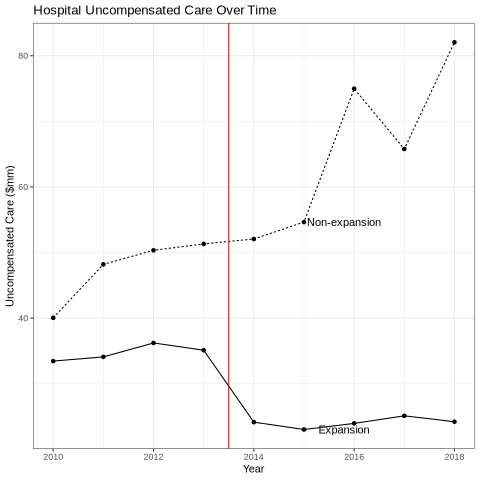

In [22]:
%%R
q2_data <- hcris.data %>%
  mutate(
    group = case_when(
      expand_year == 2014 ~ "Expansion",
      is.na(expand_year) ~ "Non-expansion",
      TRUE ~ NA_character_
    )
  ) %>%
  filter(!is.na(group))

uc.plot.dat <- q2_data %>%
  group_by(group, year) %>%
  summarise(mean = mean(uncomp_care_m, na.rm = TRUE), .groups = "drop")

uc.plot <- ggplot(
  data = uc.plot.dat,
  aes(x = year, y = mean, group = group, linetype = group)
) + 
  geom_line() + 
  geom_point() + 
  theme_bw() +
  geom_vline(xintercept = 2013.5, color = "red") +
  geom_text(
    data = uc.plot.dat %>% filter(year == 2015),
    aes(label = group, x = year + 0.8, y = mean),
    show.legend = FALSE
  ) +
  guides(linetype = "none") +
  labs(
    x = "Year",
    y = "Uncompensated Care ($mm)",
    title = "Hospital Uncompensated Care Over Time"
  )

uc.plot


#### The graph suggests a potential treatment effect. Expansion and non-expansion states are on relatively similar trajectories before 2014, although the non-expansion states are seeing a slightly steeper increase in uncompensated care. Either way, there is a marked difference in uncompensated care following 2014. This also makes intuitive sense, as it is consistent with the idea of expansion reducing uncompensated care due to greater access to insurance.

## Question 3
### Using 2012 and 2015 as your pre and post periods, present a 2x2 DD table of mean uncompensated care for expansion versus non-expansion states (again focusing only on 2014 expanders and never-expanders).

In [23]:
%%R -o q3_table
library(dplyr)
library(tidyr)

q3_data <- hcris.data %>%
  mutate(
    group = case_when(
      expand_year == 2014 ~ "Expansion",
      is.na(expand_year) ~ "Non-expansion",
      TRUE ~ NA_character_
    ),
    period = case_when(
      year == 2012 ~ "Pre (2012)",
      year == 2015 ~ "Post (2015)",
      TRUE ~ NA_character_
    ),
    period = factor(period, levels = c("Pre (2012)", "Post (2015)"))
  ) %>%
  filter(!is.na(group), !is.na(period))

q3_table <- q3_data %>%
  group_by(group, period) %>%
  summarise(
    mean_uncomp_care_m = mean(uncomp_care_m, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  mutate(mean_uncomp_care_m = round(mean_uncomp_care_m, 3)) %>%
  pivot_wider(
    names_from = period,
    values_from = mean_uncomp_care_m
  )


In [24]:
from IPython.display import Markdown, display
import pandas as pd

q3_md = q3_table.copy().fillna("")
if "group" in q3_md.columns:
    q3_md = q3_md.rename(columns={"group": "Group"})

display(Markdown("### Question 3: 2x2 Difference-in-Differences Table"))
display(Markdown(q3_md.to_markdown(index=False)))


### Question 3: 2x2 Difference-in-Differences Table

| Group         |   Pre (2012) |   Post (2015) |
|:--------------|-------------:|--------------:|
| Expansion     |       36.216 |        23.025 |
| Non-expansion |       50.344 |        54.644 |

## Question 4
### Briefly discuss what policies or events might explain the trends you observe. Why might we expect Medicaid expansion to affect uncompensated care?

#### The core logic is that Medicaid increases the amount of insured patients, particularly among low-income populations who otherwise would struggle to afford healthcare. As a result, especially given the 2014 ACA expansions, states that adopted these expansions would likely have had less trouble with a high burden of uncompensated care. 

# Estimate ATE

## Question 5
### Estimate the effect of Medicaid expansion on hospital uncompensated care using a standard DD regression estimator, focusing only on states that expanded in 2014 versus those that never expanded.

In [25]:
%%R -o q5_table
library(dplyr)

reg.dat <- hcris.data %>%
  filter(expand_year == 2014 | is.na(expand_year)) %>%
  mutate(
    post = as.integer(year >= 2014),
    treat = as.integer(expand_ever)
  )

dd.uc.reg <- lm(uncomp_care_m ~ post * treat, data = reg.dat)

coefs <- summary(dd.uc.reg)$coefficients

q5_table <- data.frame(
  Term = c("Intercept", "Post", "Expansion", "Post × Expansion"),
  Estimate = c(
    coefs["(Intercept)", "Estimate"],
    coefs["post", "Estimate"],
    coefs["treat", "Estimate"],
    coefs["post:treat", "Estimate"]
  ),
  `Std. Error` = c(
    coefs["(Intercept)", "Std. Error"],
    coefs["post", "Std. Error"],
    coefs["treat", "Std. Error"],
    coefs["post:treat", "Std. Error"]
  ),
  check.names = FALSE
)

In [26]:
from IPython.display import Markdown, display

md = "\n".join([
    "### Question 5: Difference-in-Differences Regression",
    "",
    "| Term | Estimate | Std. Error |",
    "|:--|--:|--:|",
    *[
        f"| {row['Term']} | {row['Estimate']:.3f} | {row['Std. Error']:.3f} |"
        for _, row in q5_table.iterrows()
    ]
])

display(Markdown(md))


### Question 5: Difference-in-Differences Regression

| Term | Estimate | Std. Error |
|:--|--:|--:|
| Intercept | 49.116 | 1.958 |
| Post | 15.709 | 2.547 |
| Expansion | -14.137 | 2.468 |
| Post × Expansion | -26.641 | 3.220 |

## Question 6
### Include hospital and year fixed effects in your estimates using the fixest package. Cluster your standard errors at the state level. How do your results compare to those in question 5?



In [27]:
%%R -o q6_terms
library(dplyr)
library(fixest)

reg.dat <- hcris.data %>%
  filter(expand_year == 2014 | is.na(expand_year)) %>%
  mutate(
    post = as.integer(year >= 2014),
    expand = as.integer(expand_ever),
    treat = post * expand
  )

m.dd <- lm(uncomp_care_m ~ post + expand + treat, data = reg.dat)
ct_dd <- as.data.frame(summary(m.dd)$coefficients)

m.twfe <- feols(
  uncomp_care_m ~ treat | provider_number + year,
  cluster = ~ state,
  data = reg.dat
)
ct_fe <- as.data.frame(summary(m.twfe)$coeftable)

q6_terms <- data.frame(
  Term = c("Intercept", "Post 2014", "Expansion", "Post × Expansion"),
  `Question 5 Estimate` = c(
    ct_dd["(Intercept)", "Estimate"],
    ct_dd["post", "Estimate"],
    ct_dd["expand", "Estimate"],
    ct_dd["treat", "Estimate"]
  ),
  `Question 5 Std. Error` = c(
    ct_dd["(Intercept)", "Std. Error"],
    ct_dd["post", "Std. Error"],
    ct_dd["expand", "Std. Error"],
    ct_dd["treat", "Std. Error"]
  ),
  `Question 6 TWFE Estimate` = c(
    NA, NA, NA,
    ct_fe["treat", "Estimate"]
  ),
  `Question 6 TWFE Std. Error` = c(
    NA, NA, NA,
    ct_fe["treat", "Std. Error"]
  ),
  check.names = FALSE
)


NOTE: 22,078 observations removed because of NA values (LHS: 22,078).


In [31]:
from IPython.display import Markdown, display
import pandas as pd

q6_md = q6_terms.copy().fillna("")

display(Markdown("### Question 6: Standard DD and TWFE Estimates"))
display(Markdown(q6_md.to_markdown(index=False)))


### Question 6: Standard DD and TWFE Estimates

| Term             |   Question 5 Estimate |   Question 5 Std. Error | Question 6 TWFE Estimate   | Question 6 TWFE Std. Error   |
|:-----------------|----------------------:|------------------------:|:---------------------------|:-----------------------------|
| Intercept        |               49.1161 |                 1.95796 |                            |                              |
| Post 2014        |               15.7087 |                 2.54687 |                            |                              |
| Expansion        |              -14.137  |                 2.46814 |                            |                              |
| Post × Expansion |              -26.6409 |                 3.22014 | -32.291259078073224        | 5.871774693178313            |

#### The results in 5 and 6 are relatively comparable, but 6 is a bit more negative. Question 6 uses a method that accounts for hospital and year-fixed effects, meaning that the decrease in uncompensated care looks more pronounced once we account for these factors.

## Question 7
### Repeat the analysis in question 6 but include all states (even those that expanded after 2014). Are your results different? If so, why?



In [32]:
%%R -o q7_terms
library(dplyr)
library(fixest)

reg.dat <- hcris.data %>%
  filter(expand_year == 2014 | is.na(expand_year)) %>%
  mutate(
    post = as.integer(year >= 2014),
    expand = as.integer(expand_ever),
    treat = post * expand
  )

m.twfe <- feols(
  uncomp_care_m ~ treat | provider_number + year,
  cluster = ~ state,
  data = reg.dat
)

ct_q6 <- as.data.frame(summary(m.twfe)$coeftable)

# Question 7 sample: all states, including later expanders
reg.dat.full <- hcris.data %>%
  filter(!is.na(expand_ever)) %>%
  mutate(
    treat = as.integer(if_else(expand_ever == FALSE, FALSE, year >= expand_year))
  )

m.twfe.full <- feols(
  uncomp_care_m ~ treat | provider_number + year,
  cluster = ~ state,
  data = reg.dat.full
)

ct_q7 <- as.data.frame(summary(m.twfe.full)$coeftable)

q7_terms <- data.frame(
  Term = c("Intercept", "Post 2014", "Expansion", "Treatment Effect", "Observations"),
  `Question 6 TWFE` = c(
    NA, NA, NA,
    ct_q6["treat", "Estimate"],
    nobs(m.twfe)
  ),
  `Question 7 TWFE` = c(
    NA, NA, NA,
    ct_q7["treat", "Estimate"],
    nobs(m.twfe.full)
  ),
  check.names = FALSE
)


NOTE: 22,078 observations removed because of NA values (LHS: 22,078).
NOTE: 29,861 observations removed because of NA values (LHS: 29,861).


In [33]:
from IPython.display import Markdown, display
import pandas as pd

q7_md = q7_terms.copy().fillna("")

display(Markdown("### Question 7: Restricted-Sample and All-States TWFE Estimates"))
display(Markdown(q7_md.to_markdown(index=False)))


### Question 7: Restricted-Sample and All-States TWFE Estimates

| Term             | Question 6 TWFE     | Question 7 TWFE     |
|:-----------------|:--------------------|:--------------------|
| Intercept        |                     |                     |
| Post 2014        |                     |                     |
| Expansion        |                     |                     |
| Treatment Effect | -32.291259078073224 | -25.525460574410808 |
| Observations     | 15853.0             | 21296.0             |

#### The estimate for question 7 is around 7 points greater than the estimate for question 6. In fact, the question 7 estimate is actually the most resemblant of question 5 (both around -25). When we include all states, we would see that the amount of uncompensated care is still lower for expansion states, but not as low as for 6. This is because the impact of an expansion policy takes time to truly start seeing effects. When we account for all states that expanded, even the later ones, these are states that have not yet seen all of the benefits of expansion. 

## Question 8
### Provide an “event study” graph showing the effects of Medicaid expansion in each year. Use the specification that includes hospital and year fixed effects, limited to states that expanded in 2014 or never expanded (with 2013 as the reference year).



NOTE: 22,078 observations removed because of NA values (LHS: 22,078).


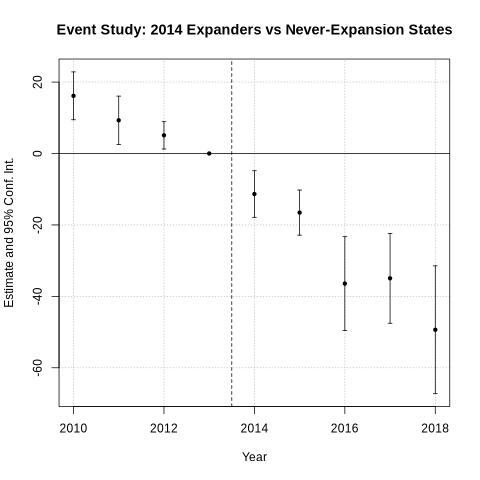

In [38]:
%%R
mod.twfe <- feols(
  uncomp_care_m ~ i(year, expand_ever, ref = 2013) | provider_number + year,
  cluster = ~ state,
  data = reg.dat
)

summary(mod.twfe)

iplot(
  mod.twfe,
  ref.line = 0,
  xlab = "Year",
  main = "Event Study: 2014 Expanders vs Never-Expansion States"
)

abline(v = 2013.5, lty = 2)


## Question 9 
### Repeat part 8 but include all states that expanded after 2014. You will need to construct an “event time” variable and bin end points as discussed in class.



NOTE: 29,861 observations removed because of NA values (LHS: 29,861).


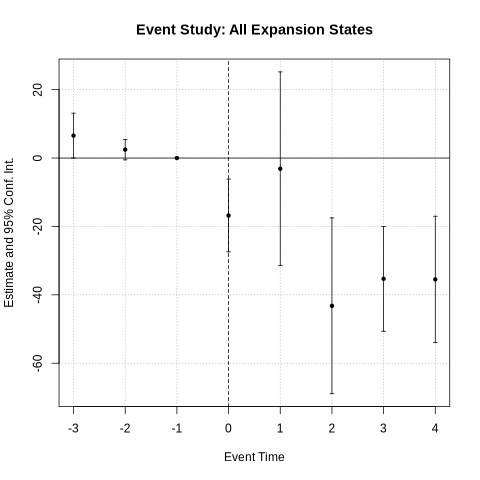

In [39]:
%%R
reg.dat.full <- hcris.data %>% 
  filter(!is.na(expand_ever)) %>%
  mutate(
    time_to_treat = if_else(expand_ever == FALSE, 0, year - expand_year),
    time_to_treat = if_else(time_to_treat < -3, -3, time_to_treat),
    time_to_treat = if_else(time_to_treat > 4, 4, time_to_treat)
  )

mod.twfe.full <- feols(
  uncomp_care_m ~ i(time_to_treat, expand_ever, ref = -1) | provider_number + year,
  cluster = ~ state,
  data = reg.dat.full
)

summary(mod.twfe.full)

iplot(
  mod.twfe.full,
  ref.line = 0,
  xlab = "Event Time",
  main = "Event Study: All Expansion States"
)


## Question 10
### As we have seen throughout this homework, Medicaid expansion, in theory, will reduce the amount of uncompensated care in the healthcare industry. As for the parallel trend assumption, 8 and 9 look relatively similar, barring some extra noise in Q9. However, there is still some concern; in question 8, there is a trend before the expansion, suggesting that the expansion and non-expansion states may have been on the same track even prior to expansion. Finally, a flaw with TWFE is that it can tend to use States that were late adopters of expansions and treat those as controls compared to early adopting states, rather than the control groups. This can bias the treatment effect of the data. 